# 🚀 Explorando o Mercado de Trabalho em Dados: Uma Análise da Arquitetura de Dados

Este projeto visa realizar uma análise aprofundada sobre o mercado de trabalho na área de dados, com foco particular na categoria **'Data Architecture and Modeling'**. Utilizando um conjunto de dados abrangente sobre empregos na indústria de tecnologia, iremos explorar salários, tendências de crescimento, porte das empresas, localização geográfica e outros fatores que moldam esta profissão crucial.

Através de técnicas de visualização de dados e estatísticas descritivas, buscaremos responder a perguntas chave sobre:
- A remuneração média para arquitetos e modeladores de dados.
- A distribuição salarial e a presença de outliers.
- A evolução da demanda por esses profissionais ao longo dos anos.
- O perfil das empresas que mais contratam nesta área.
- As principais regiões geográficas com oportunidades.

Nosso objetivo é fornecer uma visão clara e acionável para profissionais que buscam ingressar ou avançar nesta carreira, bem como para empresas que desejam entender melhor o cenário de talentos em Data Architecture and Modeling.

* 🐍 Site onde esta disponivel o banco de dados:
   - **Kaggle**: [site onde esta localizado o banco](https://www.kaggle.com/datasets/hummaamqaasim/jobs-in-data)

In [21]:
# BLOCO 1 – Importações e carregamento do dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("/content/drive/MyDrive/jobs_in_data.csv")
df.head()
df.tail()

,work_year,job_title,job_category,salary_currency,salary,salary_in_usd,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
9350,2021,Data Specialist,Data Management and Strategy,USD,165000,165000,United States,Senior,Full-time,Remote,United States,L
9351,2020,Data Scientist,Data Science and Research,USD,412000,412000,United States,Senior,Full-time,Remote,United States,L
9352,2021,Principal Data Scientist,Data Science and Research,USD,151000,151000,United States,Mid-level,Full-time,Remote,United States,L
9353,2020,Data Scientist,Data Science and Research,USD,105000,105000,United States,Entry-level,Full-time,Remote,United States,S
9354,2020,Business Data Analyst,Data Analysis,USD,100000,100000,United States,Entry-level,Contract,Remote,United States,L


### 📈Visão Geral das Categorias de Trabalho no Dataset

Antes de focar especificamente em 'Data Architecture and Modeling', vamos visualizar a distribuição geral das categorias de trabalho no dataset para entender o contexto mais amplo do mercado de dados.

/tmp/ipykernel_651/463580653.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='job_category', data=df, order=df['job_category'].value_counts().index, palette='viridis')


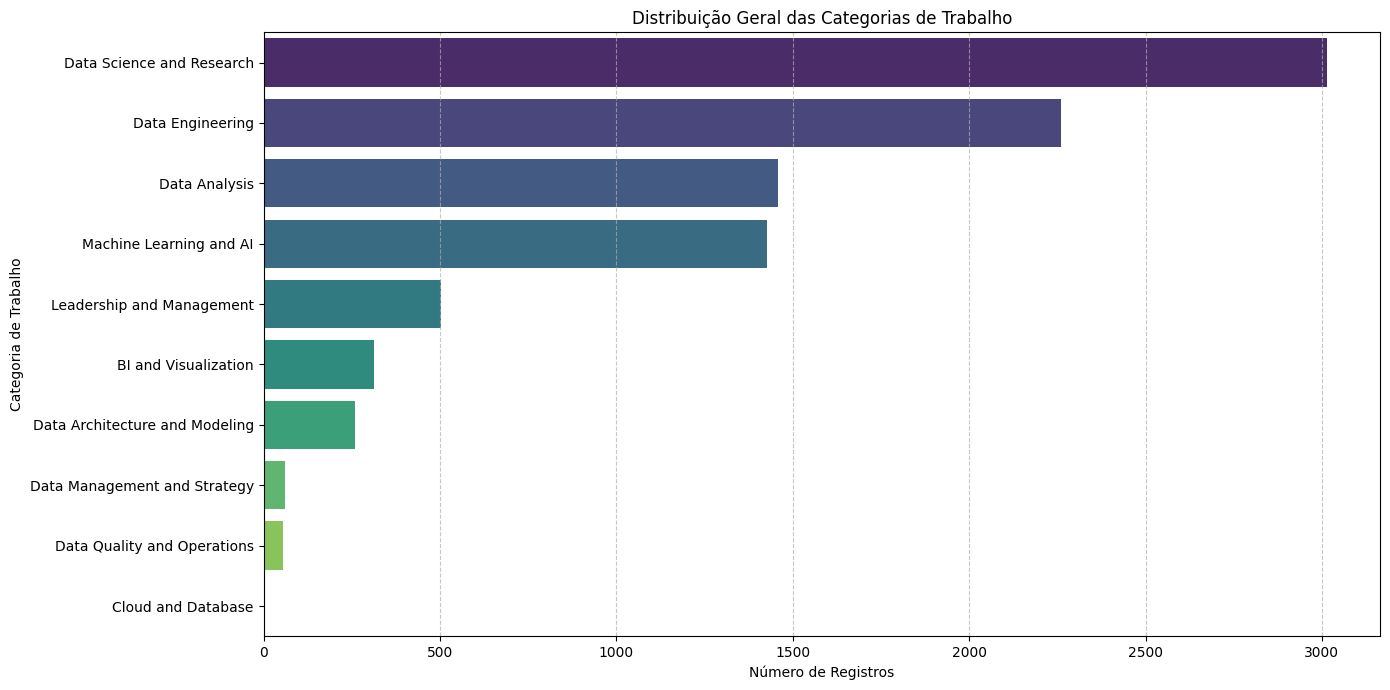

In [ ]:
plt.figure(figsize=(14, 7))
sns.countplot(y='job_category', data=df, order=df['job_category'].value_counts().index, palette='viridis')
plt.title('Distribuição Geral das Categorias de Trabalho')
plt.xlabel('Número de Registros')
plt.ylabel('Categoria de Trabalho')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# BLOCO 2 – Filtro da categoria (EXECUTE ANTES DE QUALQUER ANÁLISE)

df_cargo = df[df["job_category"] == "Data Architecture and Modeling"]

print(f"Total de registros: {len(df_cargo)}")

Total de registros: 259


# 💰 Média Salarial do Cargo

**Discussão:**

* `média salarial` → aproximadamente **USD 123.000 – 135.000/ano**
* `representatividade` → a média pode não representar bem todos os profissionais, pois a distribuição é assimétrica à direita
* `fatores` → experiência, porte da empresa, localização geográfica e demanda por arquiteturas escaláveis

In [ ]:
media_salario = df_cargo["salary_in_usd"].mean()

print(media_salario)

156002.35907335908


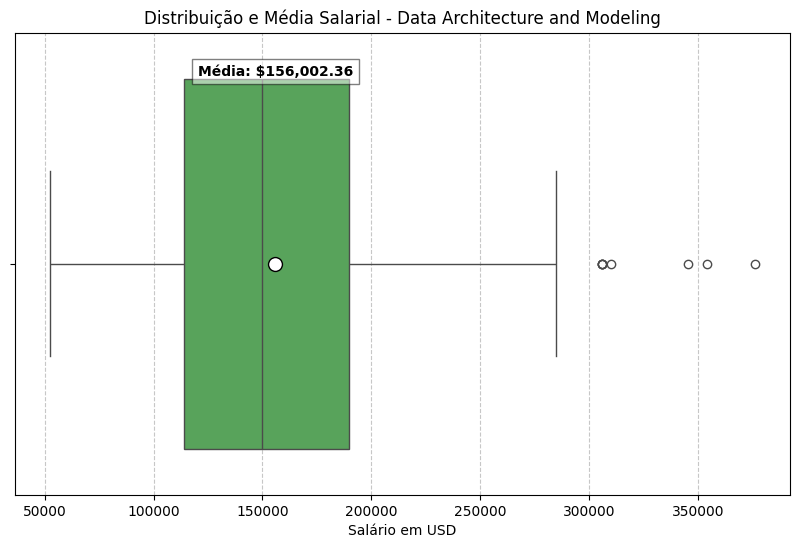

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_cargo['salary_in_usd'], color='#4CAF50', showmeans=True,
            meanprops={'marker':'o', 'markerfacecolor':'white', 'markeredgecolor':'black', 'markersize':'10'})

plt.title('Distribuição e Média Salarial - Data Architecture and Modeling')
plt.xlabel('Salário em USD')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.text(media_salario, -0.4, f'Média: ${media_salario:,.2f}',
         ha='center', va='bottom', fontweight='bold', color='black', bbox=dict(facecolor='white', alpha=0.5))

plt.show()

# 📊 Distribuição dos Salários

**Discussão:**

* `formato` → distribuição assimétrica à direita (positivamente enviesada)
* `concentração` → faixa de USD 100.000 a USD 160.000
* `outliers` → salários acima de USD 200.000, provavelmente profissionais sênior em grandes empresas americanas
* `simetria` → a maioria dos registros está abaixo da média, confirmando que ela é puxada para cima pelos valores mais altos

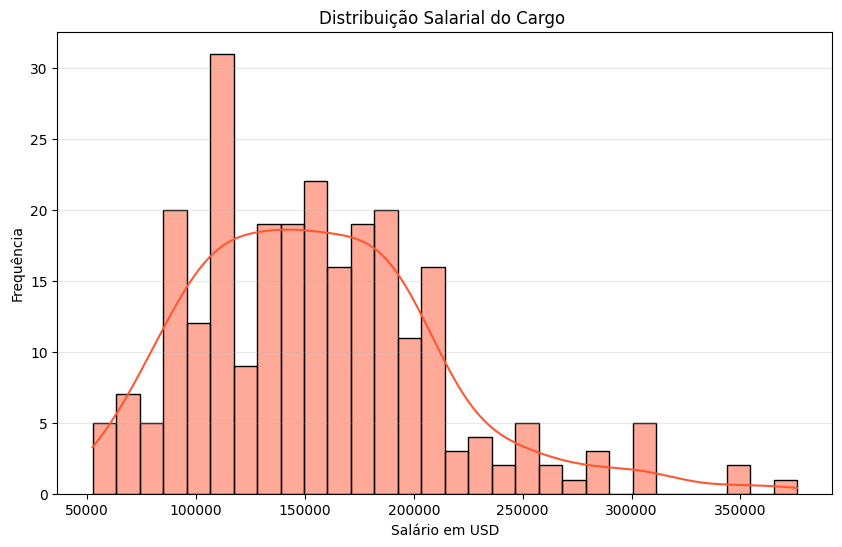

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_cargo['salary_in_usd'].dropna(), bins=30, kde=True, color='#FF5733')

plt.title('Distribuição Salarial do Cargo ')
plt.xlabel('Salário em USD')
plt.ylabel('Frequência')
plt.grid(axis='y', alpha=0.3)
plt.show()

# 📈 Frequência do Cargo ao Longo dos Anos

**Discussão:**

* `tendência` → crescimento expressivo ao longo dos anos, com salto significativo de 2022 para 2023
* `2020–2021` → poucos registros, menor demanda real ou menor cobertura do dataset
* `2022–2023` → mercado passou a valorizar e formalizar mais esse papel
* `motivo` → crescimento do volume de dados e necessidade de arquiteturas mais robustas (data lakes, data mesh, lakehouses)

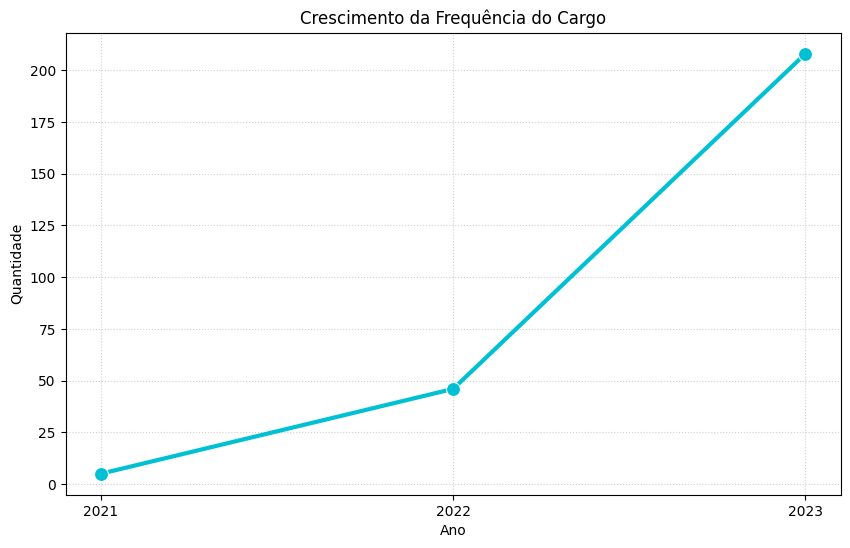

In [ ]:
frequencia_ano = df_cargo['work_year'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.lineplot(x=frequencia_ano.index, y=frequencia_ano.values, marker='o', markersize=10, color='#00C1D4', linewidth=3)

plt.title('Crescimento da Frequência do Cargo')
plt.xlabel('Ano')
plt.ylabel('Quantidade')
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(frequencia_ano.index)
plt.show()

# 💹 Porte das Empresas

**Discussão:**

* `predominância` → empresas grandes (L) dominam as contratações
* `motivo` → arquitetura de dados é função estratégica, de longo prazo e de alta complexidade
* `pequenas empresas` → costumam terceirizar ou atribuir a função a profissionais generalistas
* `empresas médias` → aparecem em segundo lugar, sugerindo descentralização gradual do cargo

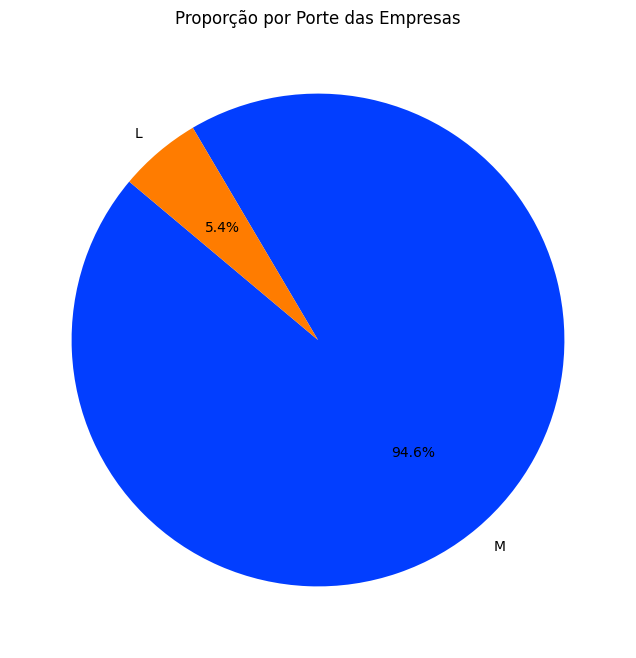

In [ ]:
porte_empresa = df_cargo['company_size'].value_counts().reindex(['M', 'L'], fill_value=0)

plt.figure(figsize=(8, 8))
plt.pie(porte_empresa.values, labels=porte_empresa.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('bright'))

plt.title('Proporção por Porte das Empresas')
plt.show()

# 🪙 Moedas Utilizadas

**Discussão:**

* `moeda dominante` → USD representa mais de 70% dos registros
* `concentração` → forte presença de empresas americanas ou que remuneram em dólar
* `outras moedas` → EUR e GBP em segundo plano, refletindo presença europeia
* `padronização` → converter para USD elimina distorções cambiais e permite comparações justas entre países

In [ ]:
moedas_tabela = df['salary_currency'].value_counts().head(5).reset_index()
moedas_tabela.columns = ['Moeda', 'Quantidade']

moedas_tabela.index = moedas_tabela.index + 1

display(moedas_tabela)

,Moeda,Quantidade
1,USD,8591
2,GBP,347
3,EUR,340
4,CAD,38
5,AUD,11


# 🏝️ Países com Mais Contratações

**Discussão:**

* `líder` → Estados Unidos com ampla vantagem
* `segundo plano` → Reino Unido e Canadá, seguidos por países europeus (DE, FR, ES, NL, PT)
* `motivo` → ecossistema tecnológico mais maduro e maior número de empresas de grande porte
* `fatores` → salários mais altos, conformidade regulatória e crescimento do mercado de analytics corporativo

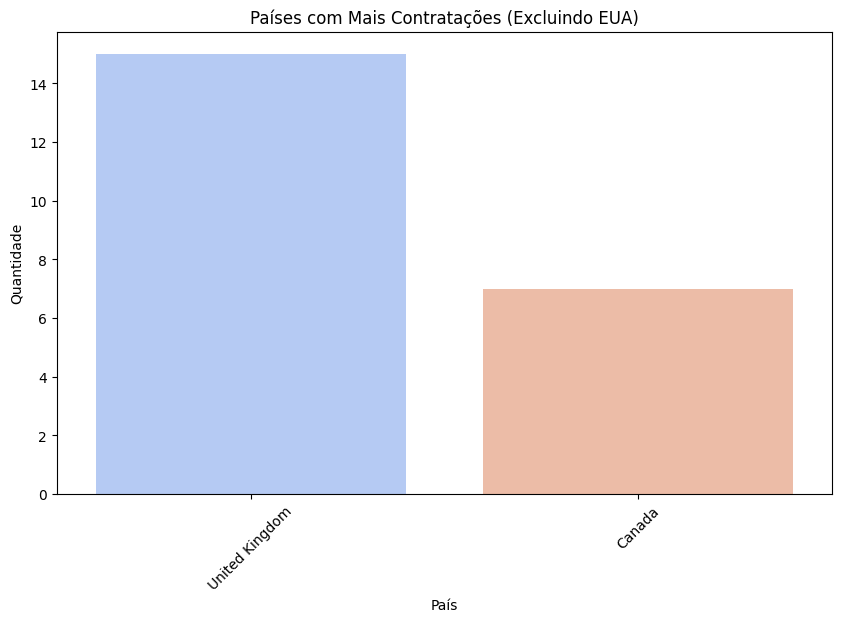

In [ ]:
paises_sem_us = df_cargo[df_cargo['company_location'] != 'United States']['company_location'].value_counts().head(10).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=paises_sem_us.index, y=paises_sem_us.values, hue=paises_sem_us.index, palette='coolwarm', legend=False)

plt.title('Países com Mais Contratações (Excluindo EUA)')
plt.xlabel('País')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.show()

## O Panorama Explosivo da Arquitetura de Dados

Este projeto revelou um cenário dinâmico e extremamente promissor para a área de **Data Architecture and Modeling**. As análises detalhadas pintam um quadro de uma profissão não apenas em ascensão meteórica, mas consolidada como um pilar estratégico no mundo corporativo.

**Pontos Chave:**

1.  **Remuneração Estelar e Crescimento Acelerado:** A média salarial robusta, com valores acima de USD 150.000 anuais, é um testemunho claro do alto valor percebido e da escassez de talentos qualificados. A distribuição assimétrica à direita, com picos entre USD 100.000 e USD 160.000, indica que a maioria dos profissionais já desfruta de salários excelentes, enquanto os *outliers* representam oportunidades ainda maiores para especialistas sênior e em empresas de ponta. Mais impressionante ainda é o **crescimento exponencial da demanda** observada entre 2022 e 2023, evidenciando que as empresas estão investindo massivamente na construção de bases de dados robustas e escaláveis.

2.  **O Império das Grandes Corporações (e o Despertar das Médias):** A esmagadora predominância de contratações por **empresas de grande porte (L)** não é coincidência. A complexidade e o volume de dados que essas organizações geram exigem arquiteturas de dados sofisticadas, tornando o Arquiteto de Dados um profissional indispensável. Contudo, a presença notável de **empresas de médio porte (M)** no cenário sugere uma descentralização gradual, onde até mesmo organizações menores começam a reconhecer a necessidade de investir em suas fundações de dados.

3.  **A Hegemonia Global do Dólar e a Concentração Geográfica:** A dominância do **Dólar Americano (USD)** como moeda de remuneração, juntamente com a liderança incontestável dos **Estados Unidos** em número de contratações, sublinha a maturidade e o dinamismo do mercado norte-americano. Países como Reino Unido, Canadá e nações europeias seguem, mas em uma escala significativamente menor, solidificando a percepção de que a vanguarda e as maiores oportunidades para esta área estão concentradas em ecossistemas tecnológicos avançados e com grande volume de dados. A padronização para USD também facilita a comparação global e a atração de talentos internacionais.

**Em síntese, a função de Data Architecture and Modeling transcendeu o status de um nicho técnico para se tornar uma competência central e estratégica.** Profissionais nesta área não são meros construtores, mas verdadeiros engenheiros de valor, capacitando empresas a transformar dados brutos em inteligência acionável. A tendência de crescimento é irreversível, impulsionada pela explosão de dados, a necessidade de *compliance* regulatório e a incessante busca por vantagem competitiva. Para quem busca uma carreira com alta demanda, remuneração excepcional e impacto significativo, a arquitetura de dados não é apenas uma escolha, mas um **destino promissor e em plena efervescência**.